best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
bestest_on_real.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


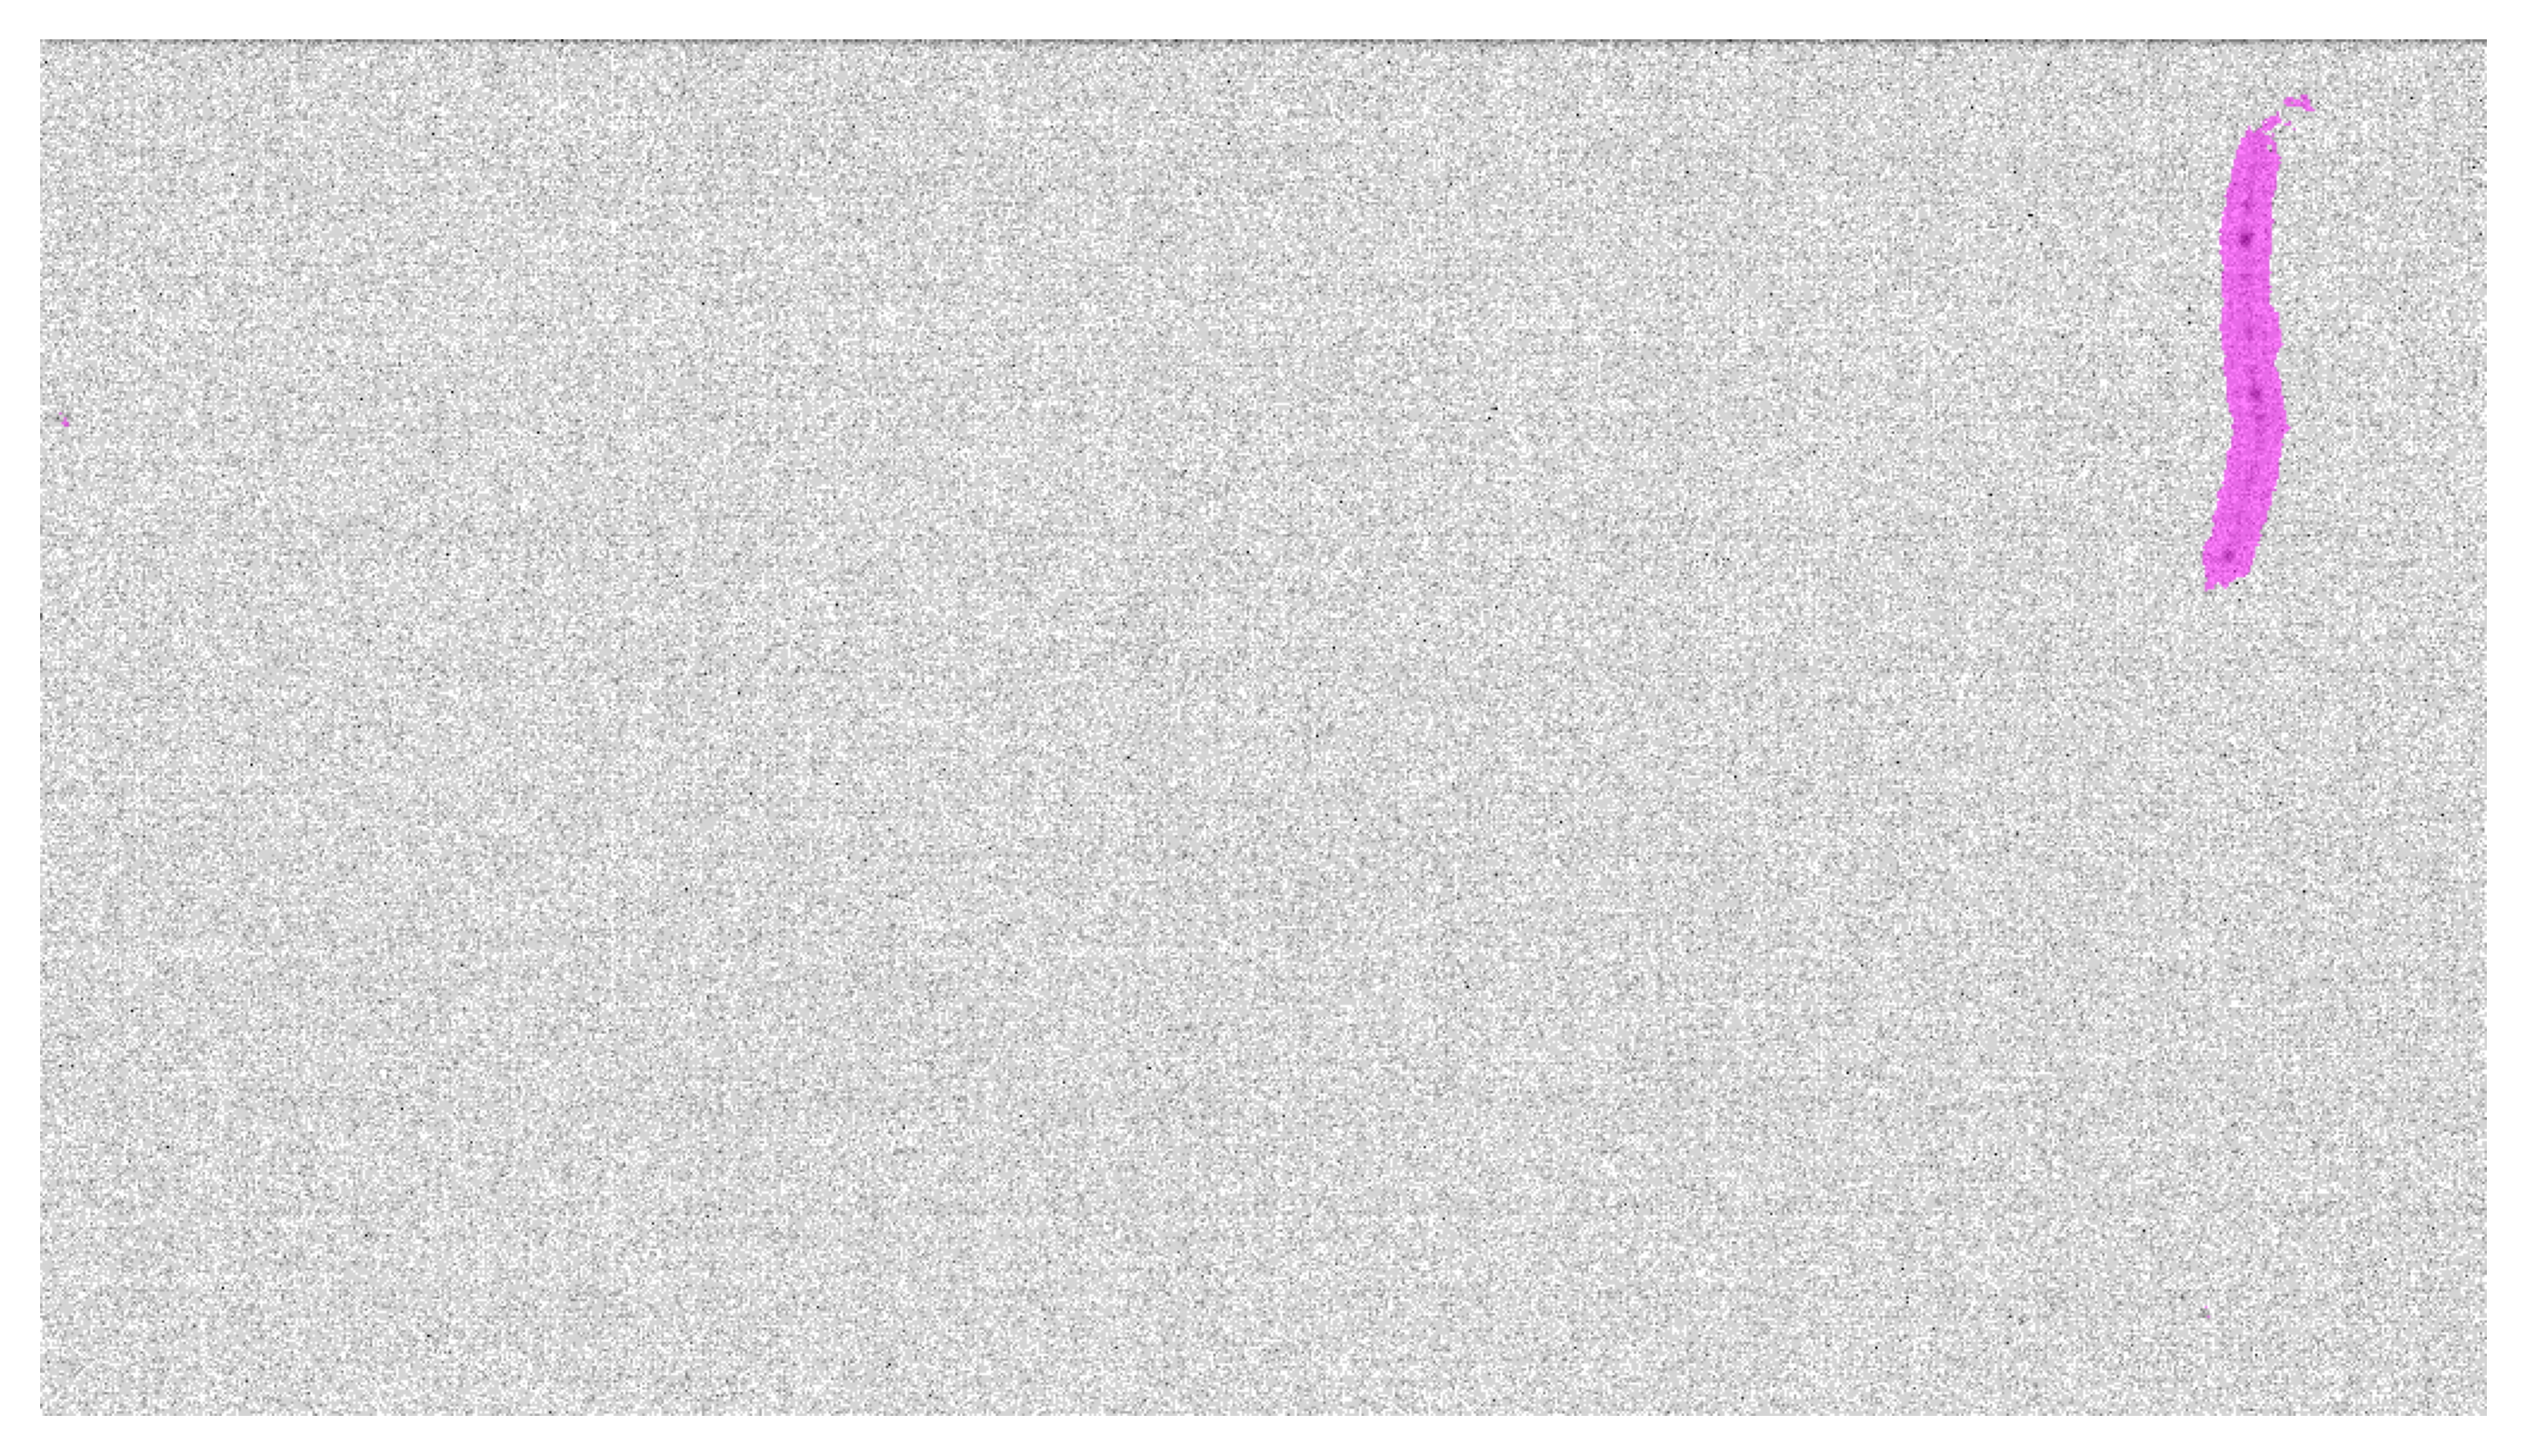

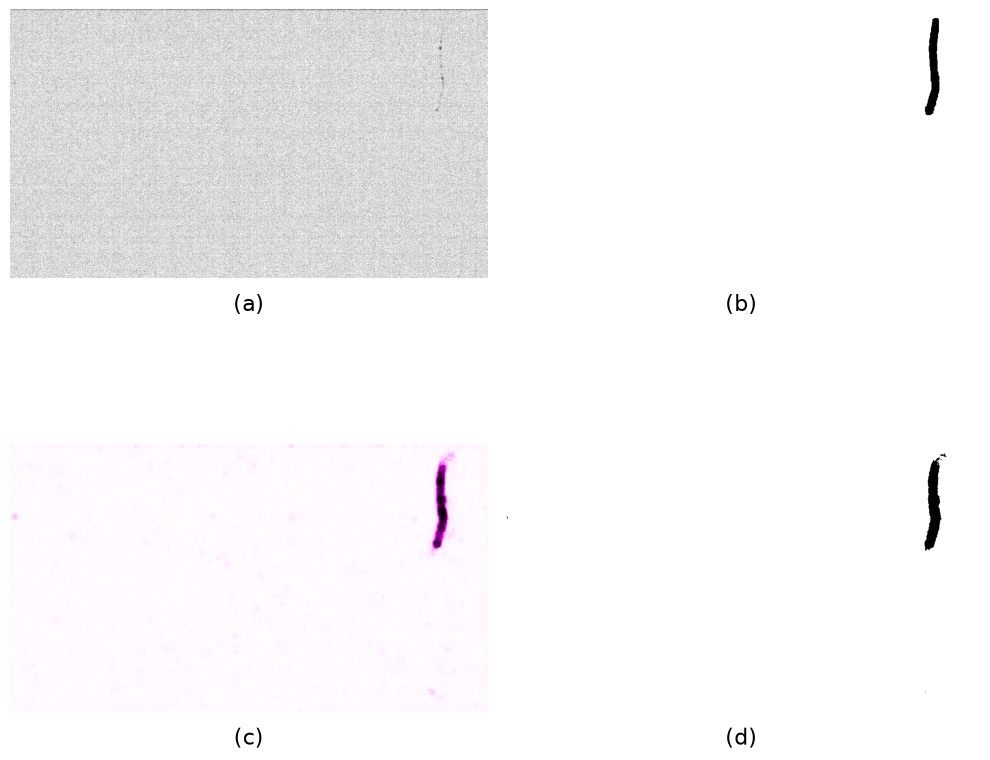

(array([[0.6666666, 0.8333333, 0.6666666, ..., 0.5      , 0.5      ,
         0.5      ],
        [0.8333333, 1.       , 0.8333333, ..., 0.8333333, 0.5      ,
         0.6666666],
        [0.8333333, 0.8333333, 0.8333333, ..., 0.8333333, 0.8333333,
         0.6666666],
        ...,
        [1.       , 0.8333333, 0.8333333, ..., 0.8333333, 0.8333333,
         0.8333333],
        [1.       , 0.8333333, 1.       , ..., 0.8333333, 0.8333333,
         0.8333333],
        [1.       , 0.8333333, 0.6666666, ..., 0.8333333, 0.8333333,
         0.8333333]], shape=(576, 1024), dtype=float32),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(576, 1024)),
 array([[0.0546659 , 0.01633674, 0.

In [45]:
import os, cygnet, torch
from matplotlib import pyplot as plt
import imageio.v3 as iio
import numpy as np
import torchvision.transforms.v2 as transforms

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

metric_test_path = "/home/frx/dataset/image_dataset/test"
raw_path = os.path.join(metric_test_path, "input")
rp_path = os.path.join(metric_test_path, "mask_exp4")

def aload_pic_pair(idx):
	raw_image_path = os.path.join(raw_path, f"i_{idx}.png")
	raw = iio.imread(raw_image_path)
	redpix_image_path = os.path.join(rp_path, f"m4_{idx}.png")
	redpix = iio.imread(redpix_image_path)

	return raw, redpix

def aget_prediction(net, input, tresh = 0.15):
	device = "cuda"

	net.eval()
	with torch.inference_mode():
		pred = net(cygnet.itrtr(input).unsqueeze(0).to(device))
	spred = torch.sigmoid(pred)
	sspred = (spred > tresh).float()

	return sspred

def acompute_energy(img):
	return img.sum()

device = "cuda"

def afull_step(net, idx, t=0.15):
		input, mask = load_pic_pair(idx)
		sspred = get_prediction(net, input, t)

		return mask, sspred

def acompute_metrics(pred, mask, eps=1e-7):
	"""
	pred: torch tensor, shape (1,1,H,W) or (1,H,W), values in {0,1}
	mask: numpy array (H,W) or (H,W,C), raw ground-truth image
	"""
	pred_np = pred.squeeze().detach().cpu().numpy().astype(bool)

	mask_np = mask
	if mask_np.ndim == 3:
		mask_np = mask_np[..., 0]  # collapse channels if present
	mask_np = (mask_np > 0)

	tp = np.logical_and(pred_np, mask_np).sum()
	fp = np.logical_and(pred_np, ~mask_np).sum()
	fn = np.logical_and(~pred_np, mask_np).sum()

	precision = tp / (tp + fp + eps)
	recall = tp / (tp + fn + eps)
	iou = tp / (tp + fp + fn + eps)
	dice = 2 * tp / (2 * tp + fp + fn + eps)

	return precision, recall, iou, dice

def avisualize_prediction(net, idx, t=0.15, alpha=0.5, vmin=199, vmax=205, is_raw=False):
	raw, mask = aload_pic_pair(idx)
	pred = aget_prediction(net, raw, t)

	pred_np = pred.squeeze().detach().cpu().numpy().astype(bool)

	if is_raw:
		pred_np=mask
	# convert raw to grayscale if it has color channels
	raw_gray = raw
	if raw_gray.ndim == 3:
		raw_gray = raw_gray.mean(axis=-1)
	raw_gray = raw_gray.astype(np.float32)

	# compress dynamic range via explicit vmin/vmax, then normalize
	v_lo = raw_gray.min() if vmin is None else vmin
	v_hi = raw_gray.max() if vmax is None else vmax
	raw_gray = np.clip(raw_gray, v_lo, v_hi)
	raw_gray = (raw_gray - v_lo) / (v_hi - v_lo + 1e-7)

	# invert so background is white, features are dark (saves ink when printed)
	raw_gray = 1.0 - raw_gray

   # build an RGB image: grayscale base, fuchsia overlay where predicted
	overlay = np.stack([raw_gray, raw_gray, raw_gray], axis=-1)
	fuchsia_layer = np.zeros_like(overlay)
	fuchsia_layer[..., 0] = 1.0  # red channel
	fuchsia_layer[..., 2] = 1.0  # blue channel

	overlay = np.where(
		pred_np[..., None],
		(1 - alpha) * overlay + alpha * fuchsia_layer,
		overlay
	)

	pathf = cygnet.figures_path + f"sparse_{idx}.pdf"

	plt.figure(dpi=500)
	plt.imshow(overlay)
	#plt.title(f"Segmentation overlay — idx {idx}")
	plt.axis("off")
	plt.tight_layout()
	plt.savefig(pathf)
	plt.show()

	#return overlay

net_file = "2026_Jul_23__16:17_best_model_base16_res_drop.pt"
net_path = os.path.join(net_folder, net_file)

net = cygnet.SkipNet(16).to(device)
net.load_state_dict(torch.load(net_path, weights_only=False)['model_state_dict'])
net.eval()

num = len(os.listdir(raw_path))
recompute = False

if recompute:
	precisions, recalls, ious, dices = [], [], [], []

	for idx in range(num):
		mask, pred = afull_step(net, idx)
		precision, recall, iou, dice = acompute_metrics(pred, mask)
		precisions.append(precision)
		recalls.append(recall)
		ious.append(iou)
		dices.append(dice)

	precisions = np.array(precisions)
	recalls = np.array(recalls)
	ious = np.array(ious)
	dices = np.array(dices)

	print(f"Mean precision: {precisions.mean():.4f} ± {precisions.std():.4f}")
	print(f"Mean recall:    {recalls.mean():.4f} ± {recalls.std():.4f}")
	print(f"Mean IoU:       {ious.mean():.4f} ± {ious.std():.4f}")
	print(f"Mean Dice:      {dices.mean():.4f} ± {dices.std():.4f}")

from matplotlib.colors import LinearSegmentedColormap

fuchsia_cmap = LinearSegmentedColormap.from_list(
	"white_fuchsia_black",
	["white", "fuchsia", "black"],
	N=256
)

def aqualitative_figure(net, idx, t=0.15, vmin=199, vmax=205, save=True):
	"""
	4-panel qualitative figure for a test-set event:
	(a) input sCMOS frame, (b) ground-truth mask,
	(c) predicted probability map, (d) binary mask after thresholding at t.
	"""
	device = "cuda"
	raw, mask = aload_pic_pair(idx)

	net.eval()
	with torch.inference_mode():
		logits = net(cygnet.itrtr(raw).unsqueeze(0).to(device))
	prob = torch.sigmoid(logits)
	binary = (prob > t).float()

	prob_np = prob.squeeze().detach().cpu().numpy()
	binary_np = binary.squeeze().detach().cpu().numpy().astype(bool)

	mask_np = mask
	if mask_np.ndim == 3:
		mask_np = mask_np[..., 0]
	mask_bin = mask_np > 0

	# raw frame: same clip/normalize/invert as avisualize_prediction
	raw_gray = raw
	if raw_gray.ndim == 3:
		raw_gray = raw_gray.mean(axis=-1)
	raw_gray = raw_gray.astype(np.float32)

	v_lo = raw_gray.min() if vmin is None else vmin
	v_hi = raw_gray.max() if vmax is None else vmax
	raw_disp = np.clip(raw_gray, v_lo, v_hi)
	raw_disp = (raw_disp - v_lo) / (v_hi - v_lo + 1e-7)
	raw_disp = 1.0 - raw_disp  # white background, dark features

	panels = [
		(raw_disp,  "gray",   "(a)"),   # already inverted: 0=dark feature, 1=white bg
		(mask_bin,  "gray_r", "(b)"),   # bool: invert so True(feature)=dark, False(bg)=white
		(prob_np,   fuchsia_cmap, "(c)"),
		(binary_np, "gray_r", "(d)"),
	]

	fig, axes = plt.subplots(2, 2, figsize=(10, 10))
	for ax, (img, cmap, label) in zip(axes.flat, panels):
		ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
		ax.axis("off")
		ax.text(0.5, -0.06, label, transform=ax.transAxes,
				ha="center", va="top", fontsize=16)

	plt.tight_layout()
	if save:
		pathf = os.path.join(cygnet.figures_path, f"qualitative_idx{idx}.pdf")
		plt.savefig(pathf, bbox_inches="tight")
	plt.show()

	return raw_disp, mask_bin, prob_np, binary_np

#824

idx = 741
avisualize_prediction(net, idx=idx, is_raw=False)
#avisualize_prediction(net, idx=idx, is_raw=True)

aqualitative_figure(net, idx=idx, t=0.15)


In [12]:
import os, cygnet, torch
from matplotlib import pyplot as plt
import imageio.v3 as iio
import numpy as np
import torchvision.transforms.v2 as transforms

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

metric_test_path = "/home/frx/dataset/image_dataset/metric_test"
raw_path = os.path.join(metric_test_path, "raw_images")
rp_path = os.path.join(metric_test_path, "redpixs")

device = "cuda"

def load_pic_pair(idx):
	raw_image_path = os.path.join(raw_path, f"raw_{idx}.png")
	raw = iio.imread(raw_image_path)
	redpix_image_path = os.path.join(rp_path, f"rp_{idx}.png")
	redpix = iio.imread(redpix_image_path)

	return raw, redpix

in_t = cygnet.input_transform_builder(4)
upscaler_t = transforms.Resize((2304, 4096), "nearest-exact", antialias = False)

def get_prediction(net, input, tresh = 0.15):
	device = "cuda"

	net.eval()
	with torch.inference_mode():
		pred = net(input.unsqueeze(0).to(device))
	spred = torch.sigmoid(pred)
	sspred = (spred > tresh).float()

	return sspred

def compute_energy(img):
	return img.sum()

def full_step(net, idx, t=0.15):
		raw, redpix = load_pic_pair(idx)
		raw_in = cygnet.itrtr(in_t(raw))
		#redpix_gt = cygnet.itrtr(in_t(redpix))
		sspred = get_prediction(net, raw_in, t)
		#mask = (redpix > 0)

		u_pred = sspred.squeeze().repeat_interleave(4, dim=0).repeat_interleave(4, dim=1)
		image = torch.from_numpy(redpix).to(device)
		masked = (image * u_pred).cpu()

		return redpix, masked, sspred

best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
bestest_on_real.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


In [3]:
import io
import numpy as np

def compress_npy_bytes(arr):
    """Size (in bytes) of arr saved as a compressed .npz, computed in memory."""
    buf = io.BytesIO()
    np.savez_compressed(buf, arr=arr)
    return buf.getbuffer().nbytes

def sparse_manual_bytes(arr, mask):
    """Size of a manual (rows, cols, vals, shape) sparse encoding, compressed."""
    rows, cols = np.nonzero(mask)
    vals = arr[rows, cols]
    buf = io.BytesIO()
    np.savez_compressed(
        buf,
        rows=rows.astype(np.uint16),
        cols=cols.astype(np.uint16),
        vals=vals.astype(np.uint16),
        shape=np.array(arr.shape, dtype=np.uint16),
    )
    return buf.getbuffer().nbytes

def reconstruct_manual(rows, cols, vals, shape):
    out = np.zeros(shape, dtype=vals.dtype)
    out[rows, cols] = vals
    return out

def check_invertibility(arr, mask):
    """Round-trip the manual sparse encoding and confirm exact reconstruction."""
    masked = arr * mask
    rows, cols = np.nonzero(mask)
    vals = arr[rows, cols]
    recon = reconstruct_manual(rows, cols, vals, arr.shape)
    return np.array_equal(recon, masked)

def get_full_res_mask(net, raw, t=0.15):
    """Run inference on the downsampled raw image and upsample the prediction
    back to raw's full resolution."""
    raw_in = cygnet.itrtr(in_t(raw))
    sspred = get_prediction(net, raw_in, t)
    u_pred = sspred.squeeze().repeat_interleave(4, dim=0).repeat_interleave(4, dim=1)
    return u_pred.cpu().numpy().astype(bool)

def storage_step(net, idx, t=0.15):
    raw, _ = load_pic_pair(idx)
    if raw.ndim == 3:
        raw = raw[..., 0]  # collapse channels if the PNG decodes as RGB
    raw = raw.astype(np.uint16)

    mask = get_full_res_mask(net, raw, t)
    assert mask.shape == raw.shape, f"mask shape {mask.shape} != raw shape {raw.shape}"

    retained_frac = mask.mean()
    if retained_frac == 0:
        return None  # empty frame, skip

    baseline_bytes = compress_npy_bytes(raw)
    manual_sparse_bytes = sparse_manual_bytes(raw, mask)
    invertible = check_invertibility(raw, mask)

    return {
        "idx": idx,
        "baseline_bytes": baseline_bytes,
        "manual_sparse_bytes": manual_sparse_bytes,
        "retained_frac": retained_frac,
        "ratio": baseline_bytes / manual_sparse_bytes,
        "invertible": invertible,
    }

def geometric_mean_std(x):
    log_x = np.log(x)
    gmean = np.exp(log_x.mean())
    gstd = np.exp(log_x.std())
    return gmean, gstd

# --- run over the test set ---

num = len(os.listdir(raw_path))
recompute_storage = True

if recompute_storage:
    raw_results = [storage_step(net, idx) for idx in range(num)]

    n_empty = sum(r is None for r in raw_results)
    results = [r for r in raw_results if r is not None]

    ratios = np.array([r["ratio"] for r in results])
    retained = np.array([r["retained_frac"] for r in results])
    all_invertible = all(r["invertible"] for r in results)

    gmean, gstd = geometric_mean_std(ratios)
    median = np.median(ratios)
    q25, q75 = np.percentile(ratios, [25, 75])

    worst = min(results, key=lambda r: r["ratio"])
    best = max(results, key=lambda r: r["ratio"])

    print(f"Skipped {n_empty}/{num} empty frames (0% retention)")
    print(f"Evaluated {len(results)} non-empty frames\n")

    print(f"Retained pixel fraction: median {np.median(retained)*100:.3f}%, "
          f"IQR [{np.percentile(retained, 25)*100:.3f}%, {np.percentile(retained, 75)*100:.3f}%]\n")

    print(f"Compression ratio (manual sparse):")
    print(f"  geometric mean: {gmean:.1f}x  (range ~{gmean/gstd:.1f}x - {gmean*gstd:.1f}x)")
    print(f"  median: {median:.1f}x, IQR [{q25:.1f}x, {q75:.1f}x]\n")

    print(f"Worst case: idx {worst['idx']}, ratio {worst['ratio']:.1f}x, "
          f"retained {worst['retained_frac']*100:.3f}%")
    print(f"Best case:  idx {best['idx']}, ratio {best['ratio']:.1f}x, "
          f"retained {best['retained_frac']*100:.3f}%\n")

    print(f"All {len(results)} representations losslessly invertible: {all_invertible}")

Skipped 0/900 empty frames (0% retention)
Evaluated 900 non-empty frames

Retained pixel fraction: median 0.078%, IQR [0.067%, 0.236%]

Compression ratio (manual sparse):
  geometric mean: 477.3x  (range ~161.4x - 1412.0x)
  median: 816.2x, IQR [297.2x, 955.4x]

Worst case: idx 546, ratio 13.8x, retained 6.560%
Best case:  idx 60, ratio 6316.0x, retained 0.000%

All 900 representations losslessly invertible: True
